# IE 206 (Introduction to Artificial Intelligence and Machine Learning)

# Bayesian Linear Regression: An Introduction

This notebook gives a introduction to **Bayesian Linear Regression**.

We start by using a very simple 1D dataset.

We will model a straight line:

$$
y = w_0 + w_1 x + \epsilon
$$

where:

- $w_0$ = intercept
- $w_1$ = slope
- $\epsilon \sim \mathcal{N}(0, \sigma^2)$ is Gaussian noise

The goal is to learn a **distribution over the parameters** instead of just one best-fit line.

This means we answer:

- What values of $w_0$ and $w_1$ are likely?
- How uncertain are we?
- How does uncertainty reduce when we see more data?

## 1. Key Idea

In ordinary linear regression, we usually compute a single (or) point estimate of the weights.

In Bayesian linear regression, we combine:

- a **prior** belief about the weights
- the **likelihood** from observed data

to get a **posterior** belief:

$$
p(\mathbf{w}\mid D)
$$

where:

$$
\mathbf{w} =
\begin{bmatrix}
w_0 \\
w_1
\end{bmatrix}
$$

and $D = \{X, y\}$ is the dataset.

#Prior, Likelihood, Posterior.

In general, we assume the weights (or) parameters of the model to be $\theta$. We assume that we have access to a dataset $D$ of observations.  

Now, one idea is to associate probability of weights $\theta$ after seeing the data, which is given as:

$$
p(\theta|D) = \frac{p(\theta,D)}{p(D)} = \frac{p(D|\theta) p(\theta)}{p(D)}.
$$

We call the probability associated with the weights $p(\theta)$ as the prior  (before seeing the data) and the term $p(D|\theta)$ as the likelihood of observing the data for a given value $\theta$ of weights, and the denominator is a normalizing constant $p(D)$.

The normalizing constant is usually found by the law of total probability as:

$$
p(D) = \int_{\Omega_\theta} p(D|\theta)p(\theta)d\theta.
$$

Since this computation of $p(D)$ is not very useful for us (or might be expensive in most cases) as it leads to the computation of a normalizing factor, we simply ignore this term and write:

$$
p(\theta|D) ∝   {p(D|\theta) p(\theta)}.
$$

$p(\theta|D)$ is called the posterior of the weights $\theta$ after seeing the data $D$.

Hence the posterior  of the model parameters  $\theta$ given a dataset $D$ of observations, is proportional to the product of the prior on $\theta$ and the likelihood of observing the data given the model.

$\large{\textbf{Model assumptions in linear regression}:}$

Typically in Linear Regression, we assume the following:

$$
y_n = \mathbf{w}^\top \mathbf{x}_n + \epsilon_n,
$$

where $y_n$ is the observed label for $n$-th sample's feature $\mathbf{x}_n$,  and $\epsilon_n \sim \mathcal{N}(0,\sigma^2)$ is a zero-mean Gaussian noise with $\sigma^2$ variance.


By this we imply that the observed label $y_n$ is a noisy realization of a true label (which is measured using the model as $\mathbf{w}^\top \mathbf{x}_n$).


### Deriving the conditional probability of $y_n$ and $\mathbf{y}$

We will assume that $\mathbf{w}$ is for now fixed and hence for a given fixed $\mathbf{x}_n$, the term $\mathbf{w}^\top \mathbf{x}_n$ is a constant.

Since

$$
\epsilon_n \sim \mathcal{N}(0,\sigma^2)
$$

and

$$
y_n = \mathbf{w}^T \mathbf{x}_n + \epsilon_n
$$

it follows that $y_n$ is also Gaussian, because adding a constant to a Gaussian random variable only shifts its mean.

So for a single observation:

$$
y_n \mid \mathbf{x}_n, \mathbf{w}, \sigma^2 \sim \mathcal{N}(\mathbf{w}^T \mathbf{x}_n,\sigma^2)
$$

Thus,

$$
p(y_n \mid \mathbf{x}_n,\mathbf{w},\sigma^2)
=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(
-\frac{1}{2\sigma^2}
(y_n-\mathbf{w}^T\mathbf{x}_n)^2
\right)
$$

---

### Joint Likelihood for All Observations

Assuming the $y_n$ to be conditionally independent given $\mathbf{x}_n$, $\mathbf{w}$ and $\sigma^2$, we have:

$$
p(\mathbf{y}\mid X,\mathbf{w},\sigma^2)
=
\prod_{n=1}^N p(y_n\mid \mathbf{x}_n,\mathbf{w},\sigma^2)
$$

Substituting the Gaussian form:

$$
p(\mathbf{y}\mid X,\mathbf{w},\sigma^2)
=
\prod_{n=1}^N
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(
-\frac{1}{2\sigma^2}
(y_n-\mathbf{w}^T\mathbf{x}_n)^2
\right)
$$

Now combine the product terms:

$$
p(\mathbf{y}\mid X,\mathbf{w},\sigma^2)
=
(2\pi\sigma^2)^{-N/2}
\exp\!\left(
-\frac{1}{2\sigma^2}
\sum_{n=1}^N (y_n-\mathbf{w}^T\mathbf{x}_n)^2
\right)
$$

---

### Matrix Form of the Likelihood

Let

$$
\mathbf{y} =
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_N
\end{bmatrix},
\qquad
X =
\begin{bmatrix}
\leftarrow \mathbf{x}_1^T \rightarrow \\
\leftarrow \mathbf{x}_2^T \rightarrow \\
\vdots \\
\leftarrow \mathbf{x}_N^T \rightarrow
\end{bmatrix}
$$

Then the vector of predicted outputs is

$$
X\mathbf{w}
=
\begin{bmatrix}
\mathbf{x}_1^T\mathbf{w} \\
\mathbf{x}_2^T\mathbf{w} \\
\vdots \\
\mathbf{x}_N^T\mathbf{w}
\end{bmatrix}
$$

Also,

$$
\sum_{n=1}^N (y_n-\mathbf{w}^T\mathbf{x}_n)^2
=
(\mathbf{y}-X\mathbf{w})^T(\mathbf{y}-X\mathbf{w})
$$

So the likelihood becomes

$$
p(\mathbf{y}\mid X,\mathbf{w},\sigma^2)
=
(2\pi\sigma^2)^{-N/2}
\exp\!\left(
-\frac{1}{2\sigma^2}
(\mathbf{y}-X\mathbf{w})^T(\mathbf{y}-X\mathbf{w})
\right)
$$

We will see shortly that this is exactly the density of a multivariate Gaussian with mean $X\mathbf{w}$ and covariance matrix $\sigma^2 I$.

### Multivariate Gaussian Density

The probability density function of a $D$-dimensional multivariate Gaussian distribution is

$$
\mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}, \Sigma)
=
\frac{1}{(2\pi)^{D/2} |\Sigma|^{1/2}}
\exp \left(
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu})^T
\Sigma^{-1}
(\mathbf{x}-\boldsymbol{\mu})
\right)
$$

where

- $\boldsymbol{\mu}$ is the **mean vector**
- $\Sigma$ is the **covariance matrix**
- $|\Sigma|$ is the **determinant of the covariance matrix**

---

### Mapping the Likelihood to a Multivariate Gaussian

We derived the likelihood

$$
p(\mathbf{y} \mid X, \mathbf{w}, \sigma^2)
=
(2\pi\sigma^2)^{-N/2}
\exp\left(
-\frac{1}{2\sigma^2}
(\mathbf{y}-X\mathbf{w})^T(\mathbf{y}-X\mathbf{w})
\right)
$$

The standard multivariate Gaussian density is

$$
p(\mathbf{y} \mid \boldsymbol{\mu}, \Sigma)
=
\frac{1}{\sqrt{(2\pi)^N |\Sigma|}}
\exp\left(
-\frac{1}{2}
(\mathbf{y}-\boldsymbol{\mu})^T
\Sigma^{-1}
(\mathbf{y}-\boldsymbol{\mu})
\right)
$$

---

### Identifying the Mean and Covariance

Compare the exponential terms.

Our expression:

$$
-\frac{1}{2\sigma^2}
(\mathbf{y}-X\mathbf{w})^T(\mathbf{y}-X\mathbf{w})
=
-\frac{1}{2}
(\mathbf{y}-X\mathbf{w})^T
\left(\frac{1}{\sigma^2}I\right)
(\mathbf{y}-X\mathbf{w})
$$

Thus we identify

$$
\boldsymbol{\mu} = X\mathbf{w}
$$

$$
\Sigma^{-1} = \frac{1}{\sigma^2}I
\qquad
\Rightarrow
\qquad
\Sigma = \sigma^2 I
$$

---

### Checking the Normalization Constant

For $\Sigma = \sigma^2 I$,

$$
|\Sigma| = (\sigma^2)^N
$$

Substituting into the Gaussian constant:

$$
\frac{1}{\sqrt{(2\pi)^N |\Sigma|}}
=
\frac{1}{\sqrt{(2\pi)^N(\sigma^2)^N}}
=
(2\pi\sigma^2)^{-N/2}
$$

which matches our derived likelihood constant.

---

### Final Result

Therefore,

$$
p(\mathbf{y}\mid X,\mathbf{w},\sigma^2)
=
\mathcal{N}(\mathbf{y}\mid X\mathbf{w},\sigma^2 I)
$$

So the likelihood of the targets is a multivariate Gaussian with mean $X\mathbf{w}$ and covariance $\sigma^2 I$.

---


Note that in the above derivation, we have computed for a given $\mathbf{w}, \sigma^2$ and the feature matrix $X$, the conditional probability (or) likelihood of the label vector $\mathbf{y}$.

Now, we will assume some prior for the parameters $\mathbf{w}$, which will drive our belief (or) intuition of possible nature of the weight parameters before seeing any observations.


Then our idea will be to update this belief using an appropriate posterior distribution that we derive for the weights.

## 2. Formulas
## Prior in Bayesian Linear Regression

Before observing any data, we place a **prior distribution** over the weight vector $w$:

$$
w \sim \mathcal{N}(m_0, S_0)
$$

This represents our **initial belief** about the weights.

---

## $m_0$ - Prior Mean

$m_0$ is the **mean of the prior distribution**.

$$
m_0 = \mathbb{E}[w]
$$

### Interpretation

- It represents our **expected value of the weights before seeing any data**.
- If we have **no prior knowledge**, we usually assume:

$$
m_0 = 0
$$

This means we initially believe the weights are centered around zero.

Example:

$$
m_0 =
\begin{bmatrix}
0 \\
0
\end{bmatrix}
$$

This indicates that both weights are expected to be close to zero before observing data.

---

## $S_0$ - Prior Covariance

$S_0$ is the **covariance matrix of the prior distribution**.

$
S_0 = \text{Cov}(w)
$

### Interpretation

It describes the **uncertainty in our belief about the weights**.

- Large covariance -> weights can vary widely.
- Small covariance -> weights are strongly constrained around the prior mean.

Example:

$$
S_0 =
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
$$

This means:

- Each weight has variance 1  
- The weights are independent

---

## $\alpha$ - Prior Precision

Many textbooks simplify the prior as:

$$
w \sim \mathcal{N}(0, \alpha^{-1} I)
$$

Here:

$$
S_0 = \alpha^{-1} I
$$

and

$$
S_0^{-1} = \alpha I
$$

So *$\alpha$* is the *precision* of the prior.

$$
\text{Precision} = \frac{1}{\text{Variance}}
$$

---

## Interpretation of $\alpha$

- **Large $\alpha$**  
  * Small variance  
  * Weights are pushed toward zero  
  * Strong regularization

- **Small $\alpha$**  
  * Large variance  
  * Weights can vary more freely  
  * Weak regularization

This Gaussian prior is equivalent to **L2 regularization (Ridge Regression)**.

---

## Relationship Between $m_0$, $S_0$, and $\alpha$

The $\alpha$-based formulation is a **special case** of the general Gaussian prior.

General prior:

$$
w \sim \mathcal{N}(m_0, S_0)
$$

Simplified prior:

$$
m_0 = 0
$$

$$
S_0 = \alpha^{-1} I
$$

So the simplified model assumes:

- Prior mean is zero  
- All weights have the same variance  
- Weights are independent  

---

## Prior Assumption for the Weights

We assume the weights follow a Gaussian prior:

$$
p(\mathbf{w}) = \mathcal{N}(\mathbf{w}\mid \mathbf{m}_0, \mathbf{S}_0)
$$

For simplicity, we use:

$$
\mathbf{m}_0 =
\begin{bmatrix}
0 \\
0
\end{bmatrix},
\qquad
\mathbf{S}_0 = \alpha^{-1} I
$$

This means that before seeing any data, we believe both weights are centered around 0 with some uncertainty.
***

### Likelihood

For $N$ observations:

$$
y_n = \mathbf{w}^T \mathbf{x}_n + \epsilon_n,
\qquad
\epsilon_n \sim \mathcal{N}(0,\sigma^2)
$$

where each input vector is written as

$$
\mathbf{x}_n = [1,\ x_n]
$$

The first entry $1$ is used for the intercept term $w_0$.

Note that we have already derived the likelihood of the targets as:

$$
p(\mathbf{y}\mid X,\mathbf{w},\sigma^2)
=
\mathcal{N}(\mathbf{y}\mid X\mathbf{w},\sigma^2 I)
$$




---



### Posterior

Because both prior and likelihood are Gaussian, the posterior is also Gaussian:

$$
p(\mathbf{w}\mid X,\mathbf{y},\sigma^2)=\mathcal{N}(\mathbf{w}\mid \mathbf{m}_N, \mathbf{S}_N)
$$

with:

$$
\mathbf{S}_N = \left(\mathbf{S}_0^{-1} + \frac{1}{\sigma^2}X^T X\right)^{-1}
$$

$$
\mathbf{m}_N = \mathbf{S}_N \left(\mathbf{S}_0^{-1}\mathbf{m}_0 + \frac{1}{\sigma^2}X^T\mathbf{y}\right)
$$

So after seeing data, our belief about the weights gets updated from prior to posterior.

### Proof that the Posterior is Gaussian

Using Bayes' rule,

$$
p(\mathbf{w}\mid X,\mathbf{y},\sigma^2)
\propto
p(\mathbf{y}\mid X,\mathbf{w},\sigma^2)\,p(\mathbf{w})
$$

We already have:

$$
p(\mathbf{y}\mid X,\mathbf{w},\sigma^2)
=
\mathcal{N}(\mathbf{y}\mid X\mathbf{w},\sigma^2 I)
$$

and the prior:

$$
p(\mathbf{w})=\mathcal{N}(\mathbf{w}\mid \mathbf{m}_0,\mathbf{S}_0)
$$

---

### Step 1: Write both densities in exponential form

Likelihood:

$$
p(\mathbf{y}\mid X,\mathbf{w},\sigma^2)
\propto
\exp\left(
-\frac{1}{2\sigma^2}
(\mathbf{y}-X\mathbf{w})^T(\mathbf{y}-X\mathbf{w})
\right)
$$

Prior:

$$
p(\mathbf{w})
\propto
\exp\left(
-\frac{1}{2}
(\mathbf{w}-\mathbf{m}_0)^T
\mathbf{S}_0^{-1}
(\mathbf{w}-\mathbf{m}_0)
\right)
$$

So,

$$
p(\mathbf{w}\mid X,\mathbf{y},\sigma^2)
\propto
\exp\left(
-\frac{1}{2\sigma^2}
(\mathbf{y}-X\mathbf{w})^T(\mathbf{y}-X\mathbf{w})
-\frac{1}{2}
(\mathbf{w}-\mathbf{m}_0)^T
\mathbf{S}_0^{-1}
(\mathbf{w}-\mathbf{m}_0)
\right)
$$

---

### Step 2: Expand the quadratic terms in $\mathbf{w}$

First expand the likelihood term:

$$
(\mathbf{y}-X\mathbf{w})^T(\mathbf{y}-X\mathbf{w})
=
\mathbf{y}^T\mathbf{y}
-2\mathbf{w}^T X^T \mathbf{y}
+\mathbf{w}^T X^T X \mathbf{w}
$$

Next expand the prior term:

$$
(\mathbf{w}-\mathbf{m}_0)^T\mathbf{S}_0^{-1}(\mathbf{w}-\mathbf{m}_0)
=
\mathbf{w}^T\mathbf{S}_0^{-1}\mathbf{w}
-2\mathbf{w}^T\mathbf{S}_0^{-1}\mathbf{m}_0
+\mathbf{m}_0^T\mathbf{S}_0^{-1}\mathbf{m}_0
$$

Substituting these back and keeping only the terms involving $\mathbf{w}$:

$$
p(\mathbf{w}\mid X,\mathbf{y},\sigma^2)
\propto
\exp\left(
-\frac{1}{2}
\left[
\mathbf{w}^T
\left(
\mathbf{S}_0^{-1}+\frac{1}{\sigma^2}X^T X
\right)\mathbf{w}
-
2\mathbf{w}^T
\left(
\mathbf{S}_0^{-1}\mathbf{m}_0+\frac{1}{\sigma^2}X^T\mathbf{y}
\right)
\right]
\right)
$$

---

### Step 3: Match with the Gaussian form

The exponent of a Gaussian in $\mathbf{w}$ has the form

$$
-\frac{1}{2}
(\mathbf{w}-\mathbf{m}_N)^T
\mathbf{S}_N^{-1}
(\mathbf{w}-\mathbf{m}_N)
$$

Comparing with the expression above, we identify

$$
\mathbf{S}_N^{-1}
=
\mathbf{S}_0^{-1}+\frac{1}{\sigma^2}X^T X
$$

hence

$$
\mathbf{S}_N
=
\left(
\mathbf{S}_0^{-1}+\frac{1}{\sigma^2}X^T X
\right)^{-1}
$$

and

$$
\mathbf{S}_N^{-1}\mathbf{m}_N
=
\mathbf{S}_0^{-1}\mathbf{m}_0+\frac{1}{\sigma^2}X^T\mathbf{y}
$$

Multiplying both sides by $\mathbf{S}_N$ gives

$$
\mathbf{m}_N
=
\mathbf{S}_N
\left(
\mathbf{S}_0^{-1}\mathbf{m}_0+\frac{1}{\sigma^2}X^T\mathbf{y}
\right)
$$

---

### Final Result

Therefore, the posterior is Gaussian:

$$
p(\mathbf{w}\mid X,\mathbf{y},\sigma^2)
=
\mathcal{N}(\mathbf{w}\mid \mathbf{m}_N,\mathbf{S}_N)
$$

with

$$
\mathbf{S}_N
=
\left(
\mathbf{S}_0^{-1}+\frac{1}{\sigma^2}X^T X
\right)^{-1}
$$

$$
\mathbf{m}_N
=
\mathbf{S}_N
\left(
\mathbf{S}_0^{-1}\mathbf{m}_0+\frac{1}{\sigma^2}X^T\mathbf{y}
\right)
$$

So after observing the data, our prior belief over the weights is updated to a posterior Gaussian distribution.


---
### Posterior Predictive Distribution

For a new input $\mathbf{x}_*$, the prediction is also Gaussian:

$$
p(y_*\mid \mathbf{x}_*, D)=\mathcal{N}(y_*\mid \mu_*, \sigma_*^2)
$$

where:

$$
\mu_* = \mathbf{x}_*^T \mathbf{m}_N
$$

$$
\sigma_*^2 = \sigma^2 + \mathbf{x}_*^T \mathbf{S}_N \mathbf{x}_*
$$

This variance has two parts:

- $\sigma^2$: noise in the data
- $\mathbf{x}_*^T \mathbf{S}_N \mathbf{x}_*$: uncertainty in the weights
---
### Proof of the Posterior Predictive Distribution

For a new input $\mathbf{x}_*$, we want the distribution of the corresponding target $y_*$ given the observed data $D=(X,\mathbf{y})$.

Using the law of total probability,

$$
p(y_* \mid \mathbf{x}_*, D)
=
\int p(y_* \mid \mathbf{x}_*, \mathbf{w}) \, p(\mathbf{w}\mid D)\, d\mathbf{w}
$$

We already know:

- The **posterior over weights** is

$$
p(\mathbf{w}\mid D)=\mathcal{N}(\mathbf{w}\mid \mathbf{m}_N,\mathbf{S}_N)
$$

- The **likelihood for a new target** is

$$
p(y_* \mid \mathbf{x}_*, \mathbf{w})
=
\mathcal{N}(y_* \mid \mathbf{x}_*^T\mathbf{w}, \sigma^2)
$$

So,

$$
p(y_* \mid \mathbf{x}_*, D)
=
\int
\mathcal{N}(y_* \mid \mathbf{x}_*^T\mathbf{w}, \sigma^2)
\,
\mathcal{N}(\mathbf{w}\mid \mathbf{m}_N,\mathbf{S}_N)
\, d\mathbf{w}
$$
One can go ahead and evaluate this integral to find the form of predictive distribution.

In the following, we will dervie a simpler way to understand the nature of the predictive distribtuion.

---

### Step 1: Express $y_*$ in terms of $\mathbf{w}$

The predictive model is

$$
y_* = \mathbf{x}_*^T \mathbf{w} + \epsilon
$$

where

$$
\epsilon \sim \mathcal{N}(0,\sigma^2)
$$

and

$$
\mathbf{w} \sim \mathcal{N}(\mathbf{m}_N,\mathbf{S}_N)
$$

Since $\mathbf{x}_*^T \mathbf{w}$ is a linear transformation of a Gaussian vector, it is also Gaussian.

Its mean is

$$
\mathbb{E}[\mathbf{x}_*^T \mathbf{w}]
=
\mathbf{x}_*^T \mathbb{E}[\mathbf{w}]
=
\mathbf{x}_*^T \mathbf{m}_N
$$

Its variance is

$$
\mathrm{Var}(\mathbf{x}_*^T \mathbf{w})
=
\mathbf{x}_*^T \mathbf{S}_N \mathbf{x}_*
$$

Thus,

$$
\mathbf{x}_*^T \mathbf{w}
\sim
\mathcal{N}
\left(
\mathbf{x}_*^T \mathbf{m}_N,\,
\mathbf{x}_*^T \mathbf{S}_N \mathbf{x}_*
\right)
$$

---

### Step 2: Add the observation noise

Now,

$$
y_* = \mathbf{x}_*^T \mathbf{w} + \epsilon
$$

where

- $\mathbf{x}_*^T \mathbf{w}$ is Gaussian
- $\epsilon$ is Gaussian
- they are independent

The sum of two independent Gaussian random variables is also Gaussian.

So $y_*$ is Gaussian with mean

$$
\mathbb{E}[y_*]
=
\mathbb{E}[\mathbf{x}_*^T \mathbf{w}] + \mathbb{E}[\epsilon]
=
\mathbf{x}_*^T \mathbf{m}_N
$$

and variance

$$
\mathrm{Var}(y_*)
=
\mathrm{Var}(\mathbf{x}_*^T \mathbf{w}) + \mathrm{Var}(\epsilon)
=
\mathbf{x}_*^T \mathbf{S}_N \mathbf{x}_* + \sigma^2
$$

Therefore,

$$
p(y_* \mid \mathbf{x}_*, D)
=
\mathcal{N}(y_* \mid \mu_*, \sigma_*^2)
$$

with

$$
\mu_* = \mathbf{x}_*^T \mathbf{m}_N
$$

$$
\sigma_*^2 = \sigma^2 + \mathbf{x}_*^T \mathbf{S}_N \mathbf{x}_*
$$

---

### Interpretation of the Predictive Variance

The predictive variance has two parts:

- $\sigma^2$: noise in the observed data
- $\mathbf{x}_*^T \mathbf{S}_N \mathbf{x}_*$: uncertainty in the estimated weights

So even if the noise were very small, predictions can still be uncertain if we are not yet confident about the weights.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(4)

## 3. Create a Simple Dataset

We will generate a small dataset from the true line:

$$
y = -0.3 + 0.5x + \epsilon
$$


In [ ]:
# True parameters
w_true = np.array([-0.3, 0.5])

# Noise standard deviation
sigma = 0.2
sigma2 = sigma**2

# Number of data points
N = 100

# Generate inputs
x = np.linspace(-3, 3, N)

# Design matrix
X = np.column_stack([np.ones_like(x), x])

# Generate noisy targets
y = X @ w_true + np.random.normal(0, sigma, size=N)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 10 rows of X:")
print(X[:10])
print("First 10 y values:")
print(np.round(y, 3)[:10])

X shape: (100, 2)
y shape: (100,)
First 10 rows of X:
[[ 1.         -3.        ]
 [ 1.         -2.93939394]
 [ 1.         -2.87878788]
 [ 1.         -2.81818182]
 [ 1.         -2.75757576]
 [ 1.         -2.6969697 ]
 [ 1.         -2.63636364]
 [ 1.         -2.57575758]
 [ 1.         -2.51515152]
 [ 1.         -2.45454545]]
First 10 y values:
[-1.79  -1.67  -1.939 -1.57  -1.762 -1.965 -1.748 -1.468 -1.491 -1.757]


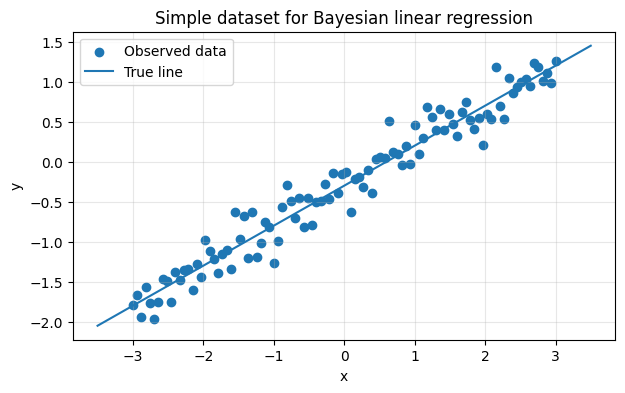

In [ ]:
plt.figure(figsize=(7, 4))
plt.scatter(x, y, label="Observed data")
x_line = np.linspace(-3.5, 3.5, 200)
y_true_line = w_true[0] + w_true[1] * x_line
plt.plot(x_line, y_true_line, label="True line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simple dataset for Bayesian linear regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Choose a Prior

We start with a simple Gaussian prior:

$$
\mathbf{w} \sim \mathcal{N}(\mathbf{m}_0, \mathbf{S}_0)
$$

Let:

$$
\mathbf{m}_0 =
\begin{bmatrix}
0 \\
0
\end{bmatrix},
\qquad
\mathbf{S}_0 =
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
$$

This says:

- before seeing data, intercept and slope are believed to be around 0
- but we are not too confident, because variance is 1

In [ ]:
m0 = np.array([0.0, 0.0])
S0 = np.array([[1.0, 0.0],
               [0.0, 1.0]])

print("Prior mean m0 =", m0)
print("Prior covariance S0 =")
print(S0)

Prior mean m0 = [0. 0.]
Prior covariance S0 =
[[1. 0.]
 [0. 1.]]


## 5. Compute the Posterior

We now implement the formulas:

$$
\mathbf{S}_N = \left(\mathbf{S}_0^{-1} + \frac{1}{\sigma^2}X^T X\right)^{-1}
$$

$$
\mathbf{m}_N = \mathbf{S}_N \left(\mathbf{S}_0^{-1}\mathbf{m}_0 + \frac{1}{\sigma^2}X^T\mathbf{y}\right)
$$

The result is a Gaussian posterior over $(w_0, w_1)$.

In [ ]:
def posterior_parameters(X, y, sigma2, m0, S0):
    S0_inv = np.linalg.inv(S0)
    SN = np.linalg.inv(S0_inv + (X.T @ X) / sigma2)
    mN = SN @ (S0_inv @ m0 + (X.T @ y) / sigma2)
    return mN, SN

mN, SN = posterior_parameters(X, y, sigma2, m0, S0)

print("Posterior mean mN =", np.round(mN, 4))
print("\nPosterior covariance SN =")
print(np.round(SN, 4))

Posterior mean mN = [-0.2928  0.5   ]

Posterior covariance SN =
[[ 0.0004 -0.    ]
 [-0.      0.0001]]


### Interpretation

- The posterior mean $\mathbf{m}_N$ gives the center of our belief about the weights.
- The posterior covariance $\mathbf{S}_N$ tells us how uncertain we still are.
- As we observe more data, $\mathbf{S}_N$ becomes smaller.

## 6. See How the Posterior Changes as Data Increases

We now compute the posterior distribution over the weights for different dataset sizes:

- $N = 0$ points
- $N = 1$ point
- $N = 10$ points
- $N = 30$ points
- $N = 50$ points
- all available points

When $N = 0$, the posterior is just the **prior**, since no data has been observed yet.

To visualize the distribution over the weights $(w_0, w_1)$, we evaluate the **Gaussian probability density function (PDF)** on a grid of possible weight values.

We create a grid of values for the two weights:

$$
w_0 \in [a,b], \qquad w_1 \in [c,d]
$$

Using this grid, the function `gaussian_pdf_grid` computes

$$
p(\mathbf{w}) =
\mathcal{N}(\mathbf{w}\mid \boldsymbol{\mu}, \Sigma)
$$

for every point $(w_0, w_1)$ on the grid.  
These density values allow us to draw **contour plots** that show regions of equal probability.

By plotting these contours for different values of $N$, we can clearly see how the posterior distribution evolves:

- with little data, the distribution is wide (high uncertainty)
- as more data is observed, the distribution becomes more concentrated
- the posterior gradually focuses on the most likely weight values

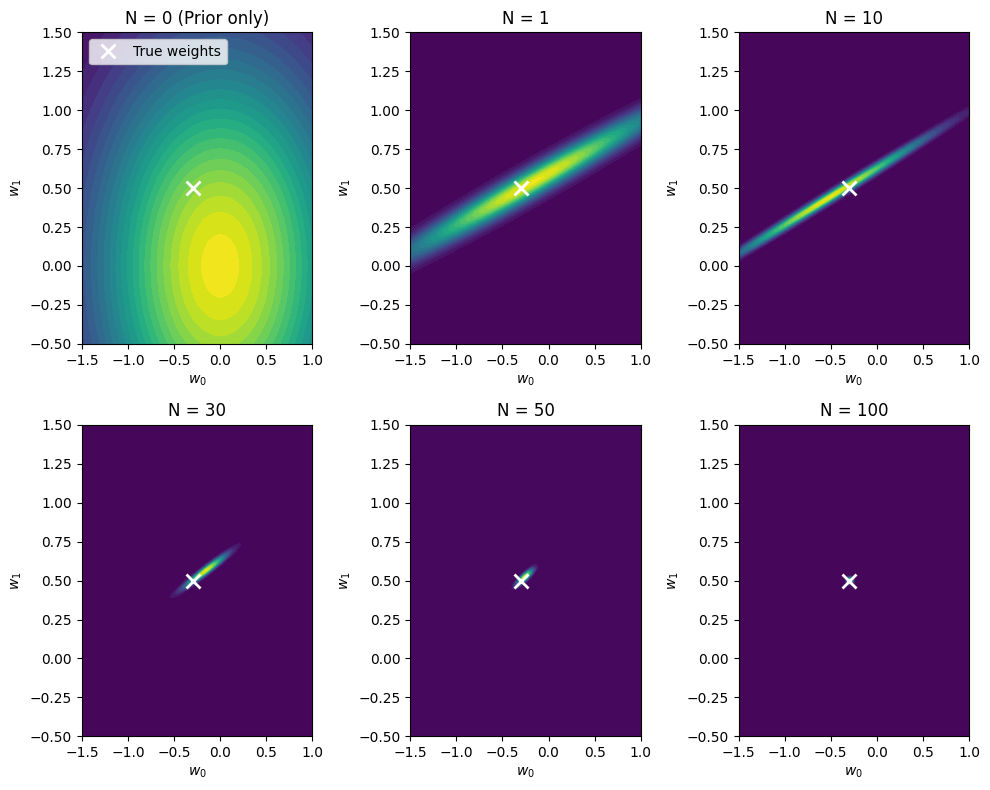

In [ ]:
def gaussian_pdf_grid(W0, W1, mean, cov):

    pos = np.stack([W0, W1], axis=-1)   # grid points (w0, w1)
    diff = pos - mean                   # (w - mean)

    cov_inv = np.linalg.inv(cov)

    quad = np.sum((diff @ cov_inv) * diff, axis=-1)   # (w-μ)^T Σ⁻¹ (w-μ)

    norm = 1 / (2 * np.pi * np.sqrt(np.linalg.det(cov)))

    return norm * np.exp(-0.5 * quad)


w0_grid = np.linspace(-1.5, 1.0, 200)
w1_grid = np.linspace(-0.5, 1.5, 200)
W0, W1 = np.meshgrid(w0_grid, w1_grid)

subsets = [0, 1, 10, 30, 50, len(x)]
titles = ["N = 0 (Prior only)", "N = 1", "N = 10", "N = 30", "N = 50", f"N = {len(x)}"]

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.ravel()

for i, (ax, n, title) in enumerate(zip(axes, subsets, titles)):
    if n == 0:
        mean, cov = m0, S0
    else:
        mean, cov = posterior_parameters(X[:n], y[:n], sigma2, m0, S0)

    Z = gaussian_pdf_grid(W0, W1, mean, cov)
    ax.contourf(W0, W1, Z, levels=25)

    ax.plot(w_true[0], w_true[1], 'wx', markersize=10, markeredgewidth=2, label="True weights")

    ax.set_title(title)
    ax.set_xlabel("$w_0$")
    ax.set_ylabel("$w_1$")

    if i == 0:
        ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

### What to Notice

- For $N=0$, the posterior is just the prior.
- For $N=1,10$ many lines can still fit one or a few points, so uncertainty is high.
- For $N=30,50$ the possible values shrink a lot.
- With all data points, the posterior concentrates around the true values.

## 7. Posterior Predictive Distribution

For any new input $x_*$, define:

$$
\mathbf{x}_* = [1,\ x_*]
$$

Then:

$$
\mu_* = \mathbf{x}_*^T \mathbf{m}_N
$$

$$
\sigma_*^2 = \sigma^2 + \mathbf{x}_*^T \mathbf{S}_N \mathbf{x}_*
$$

So the prediction is not just one value. It is a Gaussian distribution with a mean and uncertainty.

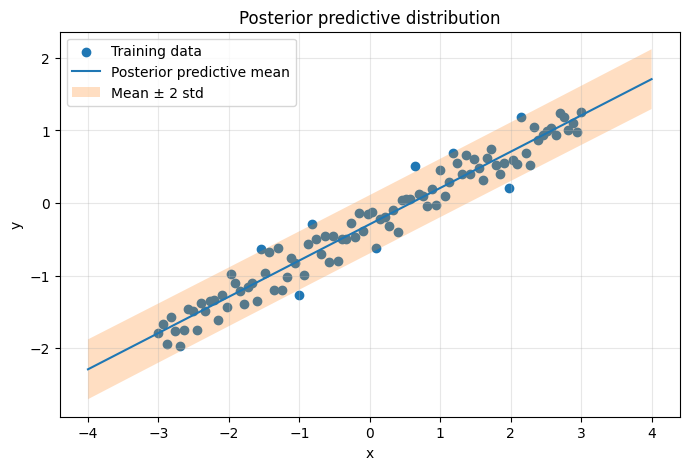

In [ ]:
def posterior_predictive(X_star, mN, SN, sigma2):
    mean = X_star @ mN
    var = sigma2 + np.sum((X_star @ SN) * X_star, axis=1)
    return mean, var

x_test = np.linspace(-4, 4, 200)
X_test = np.column_stack([np.ones_like(x_test), x_test])

pred_mean, pred_var = posterior_predictive(X_test, mN, SN, sigma2)
pred_std = np.sqrt(pred_var)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Training data")
plt.plot(x_test, pred_mean, label="Posterior predictive mean")
plt.fill_between(
    x_test,
    pred_mean - 2 * pred_std,
    pred_mean + 2 * pred_std,
    alpha=0.25,
    label="Mean ± 2 std"
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Posterior predictive distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Sample Some Lines from the Posterior

If we sample different weight vectors from:

$$
\mathbf{w}^{(s)} \sim \mathcal{N}(\mathbf{m}_N, \mathbf{S}_N)
$$

and draw the corresponding lines, we can directly see model uncertainty.

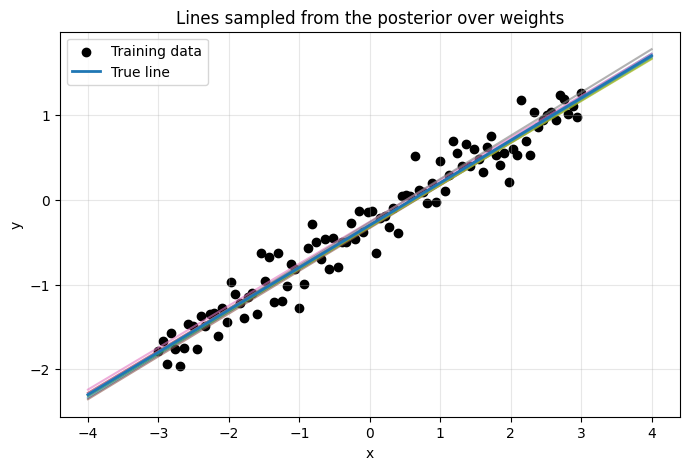

In [ ]:
samples = np.random.multivariate_normal(mean=mN, cov=SN, size=10)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="black", label="Training data")

for ws in samples:
    y_sample = ws[0] + ws[1] * x_test
    plt.plot(x_test, y_sample, alpha=0.6)

plt.plot(x_test, w_true[0] + w_true[1] * x_test, linewidth=2, label="True line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Lines sampled from the posterior over weights")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Compare with a Single Best Estimate

A common non-Bayesian approach gives a single best-fit line:

$$
\hat{\mathbf{w}} = (X^T X)^{-1}X^T y
$$

when $X^TX$ is invertible.

That gives only one answer.

Bayesian linear regression gives:

- a mean estimate
- uncertainty about parameters
- uncertainty about future predictions

In [ ]:
w_ols = np.linalg.inv(X.T @ X) @ X.T @ y
print("OLS estimate =", np.round(w_ols, 4))
print("Posterior mean =", np.round(mN, 4))
print("True weights =", w_true)

OLS estimate = [-0.2929  0.5   ]
Posterior mean = [-0.2928  0.5   ]
True weights = [-0.3  0.5]


## 10. Final Summary

Bayesian linear regression treats the weights as random variables.

### Workflow

1. Start with a prior:
   $$
p(\mathbf{w}) = \mathcal{N}(\mathbf{w}\mid \mathbf{m}_0, \mathbf{S}_0)
$$

2. Use the likelihood from data:
   $$
p(\mathbf{y}\mid X,\mathbf{w},\sigma^2)=\mathcal{N}(\mathbf{y}\mid X\mathbf{w}, \sigma^2 I)
$$

3. Compute the posterior:
   $$
p(\mathbf{w}\mid X,\mathbf{y},\sigma^2)=\mathcal{N}(\mathbf{w}\mid \mathbf{m}_N, \mathbf{S}_N)
$$

4. Predict using the posterior predictive:
   $$
p(y_*\mid \mathbf{x}_*,D)=\mathcal{N}(y_*\mid \mu_*, \sigma_*^2)
$$

### Main Takeaways

- More data usually means less uncertainty.
- The posterior becomes more concentrated as $N$ increases.
- Predictions far away from the data are more uncertain.
- This is one of the biggest strengths of the Bayesian approach.




Note: Although we visualize only two weights $(w_0, w_1)$ for clarity, all the formulas derived here apply to any number of input features. The vector $\mathbf{x}_n$ and weight vector $\mathbf{w}$ can have arbitrary dimension, making this formulation valid for general multivariable linear regression.

#References

The core content for Bayesian Linear Regression can be found in the following:

[1]. Christopher Bishop, Pattern Recognition and Machine Learning, Springer, 2006. (Chapter 3)


The material in this notebook is curated with the help of AI and NI friends.

# Credits:

$\textbf{TA:}$ Sabari Karthick

$\textbf{Instructor:}$ P. Balamurugan